# ftir_22 — the ftir_11–19 figure set re-derived under both calibration protocols

## tl;dr

The phase-3 figures that depend on the component choice, re-derived under both protocols so
every one has a Calibration-app version and a site-held-out version
(`K_SENSITIVITY_AUDIT.md` classifies the rest; the band-identity, implied-MAC and
spectra-comparison figures contain no calibration and need no update). Three results.
**(1) ftir_15's central finding is protocol-robust and, if anything, sharper.** The raw
model's Addis residuals track score-space distance under *both* protocols
(r = **0.87** Calibration app, **0.71** site-held-out) while the AIRSpec model's do not
(**0.33** / **0.21**, Spearman −0.05) — so "the raw model misses by extrapolating, the
corrected model misses by a constant offset" is a property of the spectra, not of the
component count. The site-held-out numbers reproduce ftir_15 exactly (0.714 vs the
committed 0.71). **(2) The bootstrap intercept CI survives the protocol change for the
AIRSpec model and not for the raw one**: AIRSpec gives [−2.07, −1.03] under the app
protocol against [−1.78, −1.17] site-held-out — heavily overlapping, both excluding zero —
whereas raw widens from [−4.46, −2.78] to [−6.17, −3.11]. The headline "the corrected
intercept is real and near −1.6" holds whoever calibrates. **(3) ftir_11's cohort-size
conclusion is protocol-dependent, and this is the one to correct.** Under the site-held-out
protocol N = 800 is the sweet spot (intercept −3.22, RMSE 1.16, held-out TOR R² 0.911) with
1600 worse on both. Under the Calibration app protocol the intercept and RMSE improve
**monotonically** with cohort size (−5.56 → −4.59 → −4.17; RMSE 2.28 → 2.03 → 1.60), so
that protocol would have chosen N = 1600. "800 is the right size" is a site-held-out
result, not a universal one. **(4) And an unplanned finding that fell out of reconciling this
notebook with ftir_21**: the Calibration app protocol is **not reproducible across
analysts**. Interleaved CV assigns folds by position (`i % 10`), so listing the *same 800
filters* in a different order changes the answer — ranked by OC/EC gives k = 18, the
committed cohort CSV gives k = 19, a shuffle gives k = 15, with Addis intercepts moving
correspondingly. Site-grouped CV assigns folds by site label and returns **k = 5 in all
three orderings**. Two people running the app on identical data can therefore ship
different calibrations.

## Context & Methods

ftir_21 established that the calibration **protocol** — not just the cohort — moves the
Addis answer, by up to 1.4 µg/m³ of intercept on a fixed set of filters. That raises an
obvious question about everything already committed: **which of the ftir_11–19 figures
would look different under the other protocol, and what do they look like?**

`K_SENSITIVITY_AUDIT.md` answers the first half by classifying every committed figure.
This notebook answers the second half for the figures the audit flagged as
**k-dependent and not yet re-run**, so each has a both-protocol version:

| Original | Re-derived here |
|---|---|
| `ftir15/bootstrap_intercepts.png` | Section 2 — site-cluster bootstrap under both protocols |
| `ftir15/residual_vs_D2_by_season.png` | Section 3 — residual structure under both protocols |
| `ftir11/addis_crossplots_ocec_cohorts.png` | Section 4 — cohort-size sweep under both protocols |
| `deck/mac_effect_all_calibrations.png` (ftir_19) | Section 5 — MAC pivot under both protocols |

The other categories need no work and are not repeated here: the band-identity (ftir_12),
implied-MAC (ftir_16) and spectra-comparison (ftir_17) figures contain no calibration at
all, and ftir_19's *conclusion* (MAC rescales x, so every calibration pivots on its own
intercept) is algebra that holds for any component count. Section 5 re-draws that figure
under both protocols anyway, because it is the one that shows the two arguments — MAC and
protocol — acting on the same plot.

Protocols are the two modes from `scripts/calibration_modes.py`: **Calibration app**
(10-fold interleaved CV, k = first within 5% of the minimum, fitted on all cohort
filters) and **Site-held-out** (site-grouped 5-fold CV, first-major-minimum, fitted on
the training side of a site-disjoint 80/20 split, seed 20260717).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit
from IPython.display import display

from config import season_for_month
from phase3_common import (
    PATHS, load_addis_evaluation, load_pool_metadata, load_tor_loadings,
)
from calibration_modes import (
    MODES, MODE_SHORT, SPLIT_SEED, fit_calibration, regression_metrics,
)
from pls_transfer import (
    mahalanobis_distance_squared, project_scores, score_metric, spectral_q_residual,
)

TABLE_DIR = Path('output/tables/ftir22')
PLOT_DIR = Path('output/plots/ftir22')
DECK_DIR = Path('output/plots/deck')
for directory in (TABLE_DIR, PLOT_DIR, DECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

B_BOOT = 200                       # matches ftir_15
COHORT_SIZES = (400, 800, 1600)    # matches ftir_11
INK, MUTED = '#22252A', '#6B6E75'
APP_COLOUR, HELDOUT_COLOUR = '#B23327', '#2C6E9E'
MODE_COLOUR = {'app': APP_COLOUR, 'site_heldout': HELDOUT_COLOUR}

## Data

### 1. The lowest-OC/EC cohorts, rebuilt exactly as ftir_11 built them

Ranking by TOR OC/EC over the eligible pool, then taking the N lowest — no Addis
information and no model, so cohort membership is protocol-independent here (unlike the
spectral-analog cohort; see the audit).

In [2]:
etad_eval, X_addis_raw, wavenumbers = load_addis_evaluation(season_for_month=season_for_month)
wcols = list(etad_eval.attrs['wcols'])
fabs = etad_eval['Fabs'].to_numpy(float)
volume = etad_eval['SampleVolume_m3'].to_numpy(float)
fixed_mask = etad_eval['EC_deployed_ugm3'].notna().to_numpy()
seasons = etad_eval['season'].to_numpy()

pool = (load_pool_metadata()
        .merge(load_tor_loadings(), on=['Site', 'date'], how='left', validate='many_to_one')
        .query('TOR_EC_loading_ug > 0 and OC_EC_ratio > 0')
        .drop_duplicates('FilterId')
        .sort_values('OC_EC_ratio'))
pool['AnalysisId'] = pool['AnalysisId'].astype(int)

pool_raw = pd.read_csv(PATHS.ftir_dir / 'local_db/spectra_248_251.csv',
                       usecols=['AnalysisId'] + wcols,
                       dtype={c: np.float32 for c in wcols})
pool_raw = pool_raw[~pool_raw['AnalysisId'].duplicated()].set_index('AnalysisId')
pool_raw.index = pool_raw.index.astype(int)
pool = pool[pool['AnalysisId'].isin(pool_raw.index)].drop_duplicates('AnalysisId')

cohorts = {f'lowest-OCEC {size}': pool.head(size).copy() for size in COHORT_SIZES}
for name, frame in cohorts.items():
    print(f'{name}: n={len(frame)}, sites={frame.Site.nunique()}, '
          f'OC/EC max={frame.OC_EC_ratio.max():.2f}')

# AIRSpec-corrected spectra for the 800 cohort (ftir_13's df1 = 6 run), pool and Addis.
corrected_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
corrected_row = {int(a): i for i, a in enumerate(corrected_npz['analysis_id'].astype(int))}
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
X_addis_corr = (etad_corr.groupby('MediaId').mean()
                .loc[etad_eval['MediaId'].astype(int)].to_numpy(float))

ocec800 = cohorts['lowest-OCEC 800']
ocec800 = ocec800[ocec800['AnalysisId'].isin(corrected_row)]
ids800 = ocec800['AnalysisId'].to_numpy(int)
y800 = ocec800['TOR_EC_loading_ug'].to_numpy(float)
sites800 = ocec800['Site'].to_numpy()
X800_raw = pool_raw.loc[ids800, wcols].to_numpy(float)
X800_corr = corrected_npz['corrected'][[corrected_row[i] for i in ids800]].astype(float)

SPECTRA = {
    'raw': dict(X=X800_raw, X_addis=X_addis_raw),
    'AIRSpec df1=6': dict(X=X800_corr, X_addis=X_addis_corr),
}

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


lowest-OCEC 400: n=400, sites=101, OC/EC max=1.86
lowest-OCEC 800: n=800, sites=126, OC/EC max=2.27
lowest-OCEC 1600: n=1600, sites=143, OC/EC max=2.81


### 2. Fit the OCEC-800 models under both protocols

Four models: {raw, AIRSpec} × {Calibration app, Site-held-out}. The site-held-out fits
reproduce ftir_11/ftir_13's locked k of 6 and 5.

In [3]:
fits = {}
for spectra_label, spec in SPECTRA.items():
    for mode in MODES:
        fit = fit_calibration(mode, f'lowest-OCEC 800 [{spectra_label}]',
                              spec['X'], y800, sites800, spec['X_addis'], volume)
        fits[(spectra_label, mode)] = fit
        point = regression_metrics(fabs[fixed_mask] / 10, fit.addis_ugm3[fixed_mask])
        print(f'{spectra_label:14s} {MODE_SHORT[mode]:16s} k={fit.k:2d}  '
              f"y = {point['slope']:.2f}x {point['intercept']:+.2f}")

assert fits[('raw', 'site_heldout')].k == 6, 'site-held-out raw k should reproduce ftir_11'
assert fits[('AIRSpec df1=6', 'site_heldout')].k == 5, 'should reproduce ftir_13'
print('locked component counts reproduced (raw k=6, AIRSpec k=5)')

raw            Calibration app  k=17  y = 2.15x -4.59


raw            Site-held-out    k= 6  y = 1.59x -3.22


AIRSpec df1=6  Calibration app  k=18  y = 0.97x -1.78


AIRSpec df1=6  Site-held-out    k= 5  y = 0.86x -1.62
locked component counts reproduced (raw k=6, AIRSpec k=5)


### 2b. Reproducibility check: does the row order change the answer?

Noticed while reconciling this notebook against ftir_21, which reported k = 19 and
intercept −1.65 for the AIRSpec cohort where this one gets k = 18 and −1.78 on what is
**the same 800 filters**. The cause is not a bug in either: interleaved CV assigns folds
by position (`i % 10`), so it depends on the order the cohort happens to be listed in —
and ftir_21 reads the committed ftir_11 cohort CSV while this notebook re-ranks the pool
by OC/EC. Site-grouped CV assigns folds by *site label*, so it cannot depend on row
order.

Below: the identical filter set in three orderings — ranked by OC/EC, the committed CSV
order, and a deliberate shuffle.

In [4]:
order_rows = []
shuffle_rng = np.random.default_rng(7)
committed_order = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')
committed_order = committed_order[committed_order['AnalysisId'].astype(int).isin(corrected_row)]
ORDERINGS = {
    'ranked by OC/EC': ocec800,
    'committed cohort CSV': committed_order,
    'randomly shuffled': ocec800.iloc[shuffle_rng.permutation(len(ocec800))],
}
for order_label, frame in ORDERINGS.items():
    ids = frame['AnalysisId'].to_numpy(int)
    assert set(ids) == set(ids800), 'orderings must contain the identical filter set'
    X = corrected_npz['corrected'][[corrected_row[i] for i in ids]].astype(float)
    y = frame['TOR_EC_loading_ug'].to_numpy(float)
    sites = frame['Site'].to_numpy()
    for mode in MODES:
        fit = fit_calibration(mode, 'lowest-OCEC 800 [AIRSpec]', X, y, sites,
                              X_addis_corr, volume)
        point = regression_metrics(fabs[fixed_mask] / 10, fit.addis_ugm3[fixed_mask])
        order_rows.append({'row order': order_label, 'mode': mode, 'k': fit.k,
                           'intercept': point['intercept'], 'slope': point['slope']})
order_sensitivity = pd.DataFrame(order_rows)
order_sensitivity.to_csv(TABLE_DIR / 'row_order_sensitivity.csv', index=False)
display(order_sensitivity.pivot(index='row order', columns='mode',
                                values=['k', 'intercept']).round(3))

spread = order_sensitivity.groupby('mode')['k'].agg(['min', 'max'])
print(f"Calibration app k across orderings: {spread.loc['app', 'min']}–{spread.loc['app', 'max']}"
      f" | site-held-out: {spread.loc['site_heldout', 'min']}–{spread.loc['site_heldout', 'max']}")
assert spread.loc['site_heldout', 'min'] == spread.loc['site_heldout', 'max'], \
    'site-grouped folds must not depend on row order'

k              intercept             
mode                   app site_heldout       app site_heldout
row order                                                     
committed cohort CSV  19.0          5.0    -1.650       -1.615
randomly shuffled     15.0          5.0    -1.576       -1.615
ranked by OC/EC       18.0          5.0    -1.778       -1.615

Calibration app k across orderings: 15–19 | site-held-out: 5–5


## Results

### 3. ftir_15 re-derived: the bootstrap intercept CI under both protocols

Site-cluster bootstrap, B = 200: resample training *sites* with replacement, refit at
that protocol's own k, re-measure the Addis intercept. ftir_15 reported
[−1.78, −1.06] for the AIRSpec model — that interval was conditional on k = 5, and this
is what it becomes under the other protocol.

In [5]:
rng = np.random.default_rng(SPLIT_SEED)
bootstrap_rows = []
for (spectra_label, mode), fit in fits.items():
    X = SPECTRA[spectra_label]['X']
    X_addis = SPECTRA[spectra_label]['X_addis']
    # Resample the sites this protocol actually trained on: everything for the app
    # protocol, the site-disjoint training part for the site-held-out protocol.
    if mode == 'app':
        train_index = np.arange(len(y800))
    else:
        train_index, _ = next(GroupShuffleSplit(
            n_splits=1, test_size=.20, random_state=SPLIT_SEED).split(X, groups=sites800))
    train_sites = np.unique(sites800[train_index])
    site_rows = {site: train_index[sites800[train_index] == site] for site in train_sites}

    for draw in range(B_BOOT):
        chosen = rng.choice(train_sites, size=len(train_sites), replace=True)
        rows = np.concatenate([site_rows[site] for site in chosen])
        model = PLSRegression(n_components=fit.k, scale=False).fit(X[rows], y800[rows])
        predicted = model.predict(X_addis).ravel() / volume
        bootstrap_rows.append({
            'spectra': spectra_label, 'mode': mode, 'k': fit.k, 'draw': draw,
            **regression_metrics(fabs[fixed_mask] / 10, predicted[fixed_mask]),
        })
bootstrap = pd.DataFrame(bootstrap_rows)
bootstrap.to_csv(TABLE_DIR / 'bootstrap_draws_by_mode.csv', index=False)

ci_rows = []
for (spectra_label, mode), group in bootstrap.groupby(['spectra', 'mode']):
    for metric in ('intercept', 'slope'):
        low, high = np.percentile(group[metric], [2.5, 97.5])
        ci_rows.append({'spectra': spectra_label, 'mode': mode, 'metric': metric,
                        'k': int(group['k'].iloc[0]), 'ci_low': low, 'ci_high': high,
                        'median': float(group[metric].median())})
ci = pd.DataFrame(ci_rows)
ci.to_csv(TABLE_DIR / 'bootstrap_ci_by_mode.csv', index=False)
display(ci[ci['metric'] == 'intercept'].round(3))

,spectra,mode,metric,k,ci_low,ci_high,median
0,AIRSpec df1=6,app,intercept,18,-2.072,-1.029,-1.576
2,AIRSpec df1=6,site_heldout,intercept,5,-1.777,-1.173,-1.494
4,raw,app,intercept,17,-6.165,-3.109,-4.642
6,raw,site_heldout,intercept,6,-4.457,-2.783,-3.372


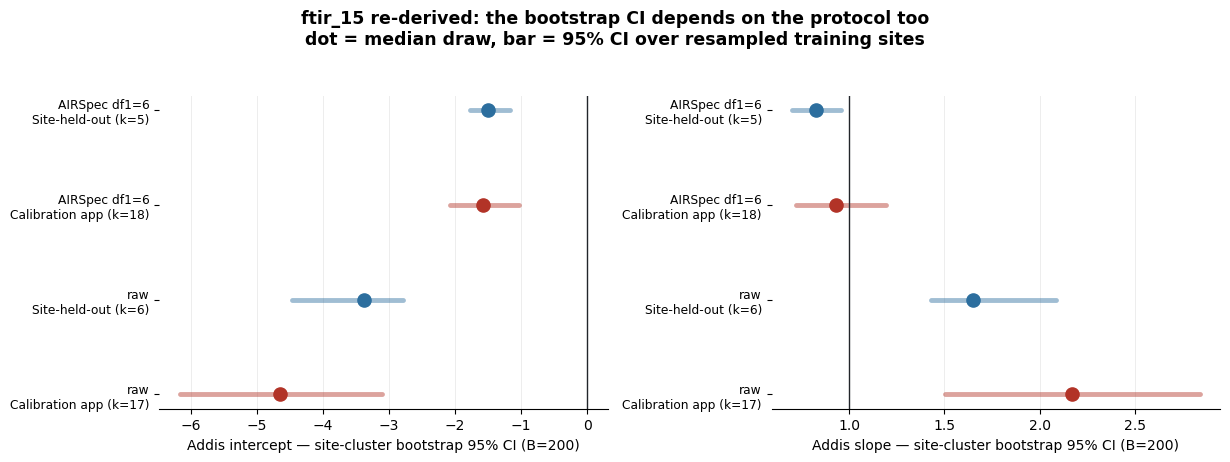

In [6]:
# Separate x-scales: intercept (µg/m³, target 0) and slope (dimensionless, target 1) are
# different quantities and sharing an axis wastes most of the slope panel's width.
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
for ax, metric, target in zip(axes, ('intercept', 'slope'), (0.0, 1.0)):
    offset = 0
    labels = []
    for spectra_label in SPECTRA:
        for mode in MODES:
            group = bootstrap[(bootstrap['spectra'] == spectra_label)
                              & (bootstrap['mode'] == mode)][metric]
            low, high = np.percentile(group, [2.5, 97.5])
            ax.plot([low, high], [offset, offset], color=MODE_COLOUR[mode], lw=3.5,
                    alpha=.45, solid_capstyle='round')
            ax.scatter([group.median()], [offset], color=MODE_COLOUR[mode], s=90, zorder=3)
            labels.append(f'{spectra_label}\n{MODE_SHORT[mode]} (k={fits[(spectra_label, mode)].k})')
            offset += 1
    ax.axvline(target, color=INK, lw=1)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8.8)
    ax.set_xlabel(f'Addis {metric} — site-cluster bootstrap 95% CI (B={B_BOOT})')
    ax.grid(axis='x', color='0.93', lw=.7)
    ax.set_axisbelow(True)
    for spine in ('top', 'right', 'left'):
        ax.spines[spine].set_visible(False)
fig.suptitle('ftir_15 re-derived: the bootstrap CI depends on the protocol too\n'
             'dot = median draw, bar = 95% CI over resampled training sites',
             y=1.04, fontsize=12.5, fontweight='bold')
fig.tight_layout()
for target_path in (PLOT_DIR / 'bootstrap_intercepts_by_mode.png',
                    DECK_DIR / 'bootstrap_intercepts_by_mode.png'):
    fig.savefig(target_path, dpi=190, bbox_inches='tight', facecolor='white')
plt.show()

### 4. ftir_15 re-derived: residual structure vs distance from the calibration cloud

ftir_15's sharpest result was that the *raw* model's Addis residuals track score-space
distance D² (r = 0.71, extrapolation-driven) while the *corrected* model's do not
(season-stable offset). Both were measured at the locked k — this checks whether the
distinction is a property of the spectra or of the component count.

In [7]:
diagnostic_rows, residual_frames = [], {}
for (spectra_label, mode), fit in fits.items():
    model = fit.model
    X_addis = SPECTRA[spectra_label]['X_addis']
    scores_train, inverse_ss = score_metric(model)
    d2 = mahalanobis_distance_squared(project_scores(model, X_addis), inverse_ss)
    q = spectral_q_residual(model, X_addis)
    residual = fit.addis_ugm3 - fabs / 10
    frame = pd.DataFrame({'season': seasons, 'D2': d2, 'Q': q, 'Fabs': fabs,
                          'residual_ugm3': residual, 'fixed': fixed_mask})
    residual_frames[(spectra_label, mode)] = frame
    keep = frame.dropna(subset=['D2', 'residual_ugm3'])
    diagnostic_rows.append({
        'spectra': spectra_label, 'mode': mode, 'k': fit.k,
        'pearson_r_residual_vs_D2': pearsonr(keep['D2'], keep['residual_ugm3'])[0],
        'spearman_r_residual_vs_D2': spearmanr(keep['D2'], keep['residual_ugm3'])[0],
        'mean_residual': float(keep['residual_ugm3'].mean()),
        'sd_residual': float(keep['residual_ugm3'].std()),
    })
diagnostics = pd.DataFrame(diagnostic_rows)
diagnostics.to_csv(TABLE_DIR / 'residual_drivers_by_mode.csv', index=False)
# Per-filter export so the standalone per-protocol figures can be rebuilt without refitting
# (scripts/build_protocol_variants.py).
pd.concat([frame.assign(spectra=spectra_label, mode=mode, k=fits[(spectra_label, mode)].k)
           for (spectra_label, mode), frame in residual_frames.items()]
          ).to_csv(TABLE_DIR / 'addis_residuals_by_mode.csv', index=False)
display(diagnostics.round(3))

,spectra,mode,k,pearson_r_residual_vs_D2,spearman_r_residual_vs_D2,mean_residual,sd_residual
0,raw,app,17,0.872,0.822,0.793,1.758
1,raw,site_heldout,6,0.714,0.771,-0.520,1.125
2,AIRSpec df1=6,app,18,0.332,0.193,-1.989,0.706
3,AIRSpec df1=6,site_heldout,5,0.209,-0.048,-2.352,0.716


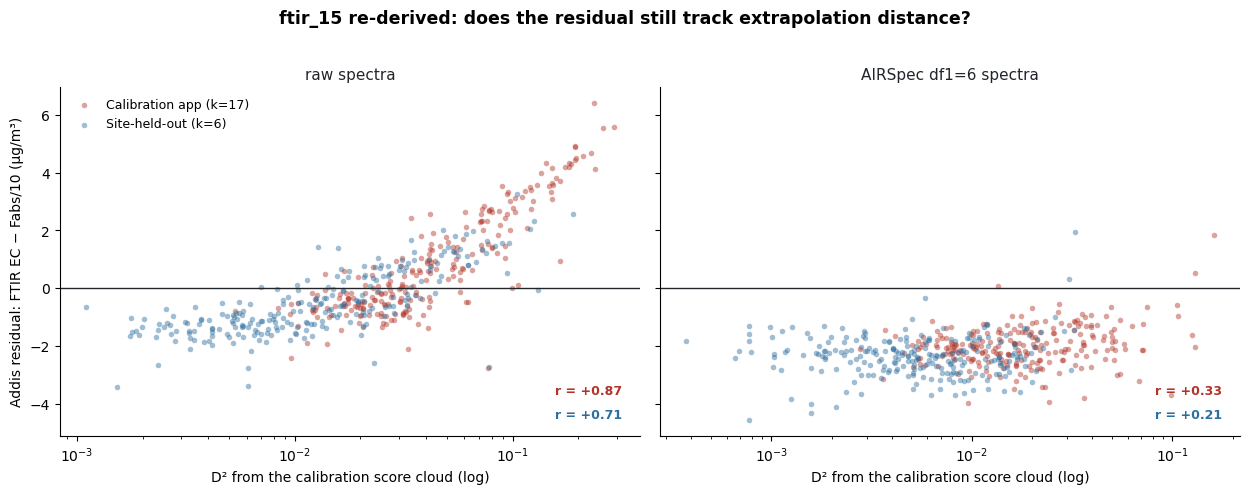

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8), sharey=True)
for ax, spectra_label in zip(axes, SPECTRA):
    for mode in MODES:
        frame = residual_frames[(spectra_label, mode)]
        ax.scatter(frame['D2'], frame['residual_ugm3'], s=16, alpha=.45,
                   color=MODE_COLOUR[mode], lw=0,
                   label=f'{MODE_SHORT[mode]} (k={fits[(spectra_label, mode)].k})')
        row = diagnostics[(diagnostics['spectra'] == spectra_label)
                          & (diagnostics['mode'] == mode)].iloc[0]
        ax.annotate(f"r = {row['pearson_r_residual_vs_D2']:+.2f}",
                    xy=(.97, .12 if mode == 'app' else .05), xycoords='axes fraction',
                    ha='right', fontsize=9, color=MODE_COLOUR[mode], fontweight='bold')
    ax.axhline(0, color=INK, lw=1)
    ax.set_xscale('log')
    ax.set_title(f'{spectra_label} spectra', fontsize=11, color=INK)
    ax.set_xlabel('D² from the calibration score cloud (log)')
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel('Addis residual: FTIR EC − Fabs/10 (µg/m³)')
axes[0].legend(frameon=False, fontsize=9, loc='upper left')
fig.suptitle('ftir_15 re-derived: does the residual still track extrapolation distance?',
             y=1.02, fontsize=12.5, fontweight='bold')
fig.tight_layout()
for target_path in (PLOT_DIR / 'residual_vs_D2_by_mode.png',
                    DECK_DIR / 'residual_vs_D2_by_mode.png'):
    fig.savefig(target_path, dpi=190, bbox_inches='tight', facecolor='white')
plt.show()

### 5. ftir_11 re-derived: the cohort-size sweep under both protocols

ftir_11 compared N = 400 / 800 / 1600 and concluded 400 is too small to support a model
and 1600 dilutes the effect. Both conclusions were drawn at site-held-out k; this checks
whether they survive the other protocol.

In [9]:
sweep_rows = []
for size in COHORT_SIZES:
    frame = cohorts[f'lowest-OCEC {size}']
    ids = frame['AnalysisId'].to_numpy(int)
    X = pool_raw.loc[ids, wcols].to_numpy(float)
    y = frame['TOR_EC_loading_ug'].to_numpy(float)
    sites = frame['Site'].to_numpy()
    for mode in MODES:
        fit = fit_calibration(mode, f'lowest-OCEC {size}', X, y, sites, X_addis_raw, volume)
        point = regression_metrics(fabs[fixed_mask] / 10, fit.addis_ugm3[fixed_mask])
        sweep_rows.append({
            'cohort_size': size, 'mode': mode, 'k': fit.k,
            'heldout_TOR_R2': fit.heldout['R2'] if fit.heldout else np.nan,
            **{key: point[key] for key in ('slope', 'intercept', 'R2', 'RMSE')},
        })
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(TABLE_DIR / 'cohort_size_sweep_by_mode.csv', index=False)
display(sweep.round(3))

,cohort_size,mode,k,heldout_TOR_R2,slope,intercept,R2,RMSE
0,400,app,5,NaN,2.360,-5.564,0.761,2.283
1,400,site_heldout,3,0.191,2.231,-5.288,0.762,1.997
2,800,app,17,NaN,2.147,-4.593,0.761,2.034
3,800,site_heldout,6,0.911,1.585,-3.222,0.774,1.159
4,1600,app,11,NaN,1.940,-4.166,0.749,1.611
5,1600,site_heldout,9,0.793,1.655,-3.449,0.752,1.250


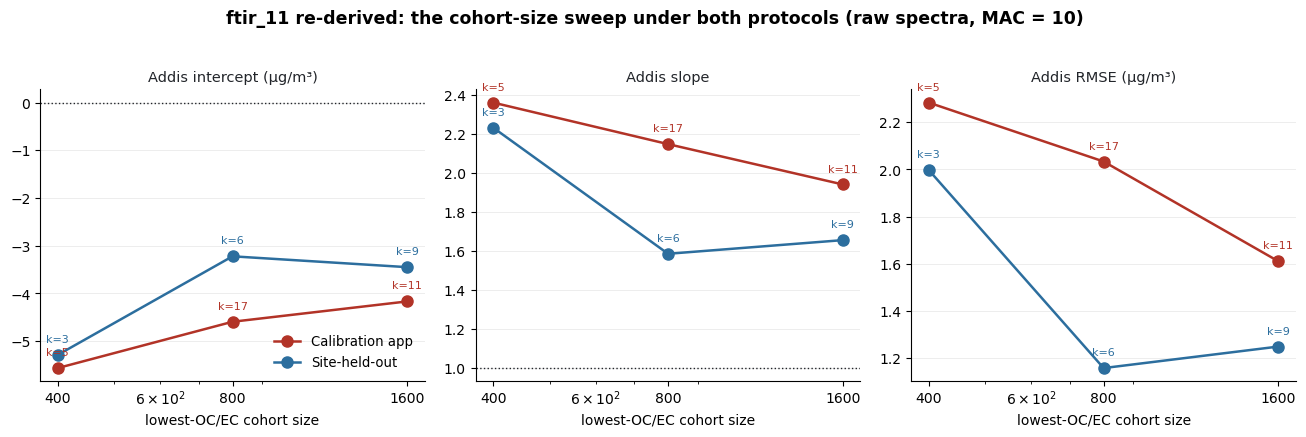

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2))
for ax, metric, target, title in zip(
        axes, ('intercept', 'slope', 'RMSE'), (0.0, 1.0, None),
        ('Addis intercept (µg/m³)', 'Addis slope', 'Addis RMSE (µg/m³)')):
    for mode in MODES:
        part = sweep[sweep['mode'] == mode]
        ax.plot(part['cohort_size'], part[metric], '-o', color=MODE_COLOUR[mode],
                lw=1.8, ms=8, label=MODE_SHORT[mode])
        for _, row in part.iterrows():
            ax.annotate(f"k={int(row['k'])}", (row['cohort_size'], row[metric]),
                        textcoords='offset points', xytext=(0, 9), ha='center',
                        fontsize=8, color=MODE_COLOUR[mode])
    if target is not None:
        ax.axhline(target, color=INK, lw=1, ls=':')
    ax.set_xscale('log')
    ax.set_xticks(COHORT_SIZES)
    ax.set_xticklabels([str(s) for s in COHORT_SIZES])
    ax.set_xlabel('lowest-OC/EC cohort size')
    ax.set_title(title, fontsize=10.5, color=INK)
    ax.grid(axis='y', color='0.93', lw=.7)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
axes[0].legend(frameon=False, fontsize=9.5)
fig.suptitle('ftir_11 re-derived: the cohort-size sweep under both protocols '
             '(raw spectra, MAC = 10)', y=1.03, fontsize=12.5, fontweight='bold')
fig.tight_layout()
for target_path in (PLOT_DIR / 'cohort_size_sweep_by_mode.png',
                    DECK_DIR / 'cohort_size_sweep_by_mode.png'):
    fig.savefig(target_path, dpi=190, bbox_inches='tight', facecolor='white')
plt.show()

### 6. ftir_19 re-derived: the MAC pivot under both protocols

The two arguments on one plot. Each calibration pivots around its own intercept when MAC
changes (ftir_19, algebra — protocol-independent); the protocol moves where that pivot
sits (ftir_21). Filled/solid = MAC 10, open/dashed = MAC 6.

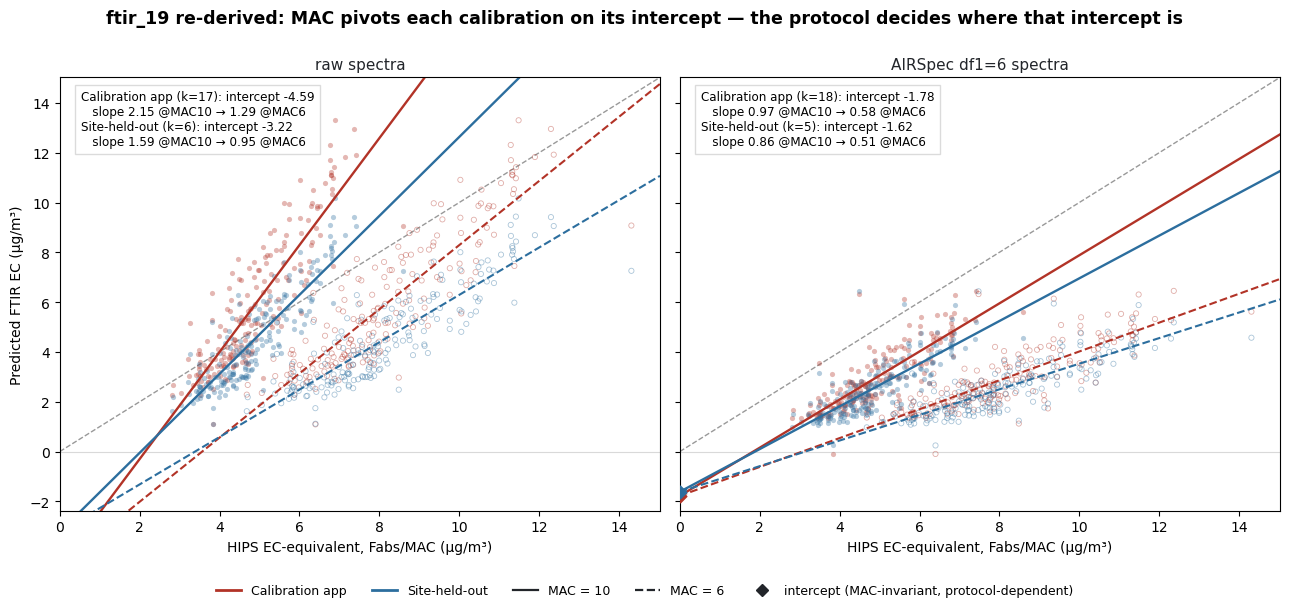

In [11]:
x10, x6 = fabs / 10, fabs / 6
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.6), sharex=True, sharey=True)
for ax, spectra_label in zip(axes, SPECTRA):
    hi = float(max(np.nanmax(x6[fixed_mask]),
                   max(np.nanmax(fits[(spectra_label, m)].addis_ugm3[fixed_mask])
                       for m in MODES))) * 1.05
    lo = min(0.0, min(float(regression_metrics(
        x10[fixed_mask], fits[(spectra_label, m)].addis_ugm3[fixed_mask])['intercept'])
        for m in MODES)) - .6
    ax.plot([0, hi], [0, hi], '--', color='0.6', lw=1, zorder=1)
    ax.axhline(0, color='0.85', lw=.8, zorder=0)
    for mode in MODES:
        prediction = fits[(spectra_label, mode)].addis_ugm3[fixed_mask]
        stats10 = regression_metrics(x10[fixed_mask], prediction)
        stats6 = regression_metrics(x6[fixed_mask], prediction)
        colour = MODE_COLOUR[mode]
        ax.scatter(x10[fixed_mask], prediction, s=14, alpha=.35, color=colour, lw=0)
        ax.scatter(x6[fixed_mask], prediction, s=14, alpha=.4, facecolors='none',
                   edgecolors=colour, lw=.6)
        ax.plot([0, hi], [stats10['intercept'], stats10['slope'] * hi + stats10['intercept']],
                '-', color=colour, lw=1.7)
        ax.plot([0, hi], [stats6['intercept'], stats6['slope'] * hi + stats6['intercept']],
                '--', color=colour, lw=1.5)
        ax.scatter([0], [stats10['intercept']], marker='D', s=42, color=colour, zorder=5)
    text = []
    for mode in MODES:
        prediction = fits[(spectra_label, mode)].addis_ugm3[fixed_mask]
        s10 = regression_metrics(x10[fixed_mask], prediction)
        s6 = regression_metrics(x6[fixed_mask], prediction)
        text.append(f"{MODE_SHORT[mode]} (k={fits[(spectra_label, mode)].k}): "
                    f"intercept {s10['intercept']:+.2f}\n"
                    f"   slope {s10['slope']:.2f} @MAC10 → {s6['slope']:.2f} @MAC6")
    ax.text(.035, .97, '\n'.join(text), transform=ax.transAxes, va='top', fontsize=8.6,
            bbox=dict(facecolor='white', edgecolor='0.85', alpha=.93))
    ax.set_xlim(0, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(f'{spectra_label} spectra', fontsize=11, color=INK)
    ax.set_xlabel('HIPS EC-equivalent, Fabs/MAC (µg/m³)')
axes[0].set_ylabel('Predicted FTIR EC (µg/m³)')
fig.legend(handles=[
    Line2D([], [], color=APP_COLOUR, lw=2, label='Calibration app'),
    Line2D([], [], color=HELDOUT_COLOUR, lw=2, label='Site-held-out'),
    Line2D([], [], color=INK, lw=1.6, ls='-', label='MAC = 10'),
    Line2D([], [], color=INK, lw=1.6, ls='--', label='MAC = 6'),
    Line2D([], [], color=INK, marker='D', ls='', markersize=6,
           label='intercept (MAC-invariant, protocol-dependent)'),
], loc='lower center', ncol=5, frameon=False, bbox_to_anchor=(.5, -.07), fontsize=9)
fig.suptitle('ftir_19 re-derived: MAC pivots each calibration on its intercept — '
             'the protocol decides where that intercept is', y=1.0,
             fontsize=12.5, fontweight='bold')
fig.tight_layout()
for target_path in (PLOT_DIR / 'mac_pivot_by_mode.png',
                    DECK_DIR / 'mac_pivot_by_mode.png'):
    fig.savefig(target_path, dpi=190, bbox_inches='tight', facecolor='white')
plt.show()

### 7. The index: every ftir_11–19 figure and where its updated version lives

Committed as a table so the deck can be assembled without re-reading the audit.

In [12]:
INDEX = pd.DataFrame([
    ('ftir_11', 'addis_crossplots_ocec_cohorts.png', 'k-dependent',
     'ftir22/cohort_size_sweep_by_mode.png + ftir21/both_modes_crossplots.png'),
    ('ftir_11', 'cohort_cut_and_cv_curves.png', 'k-dependent',
     'ftir20/component_selection_all_setups.png (four curves per cohort)'),
    ('ftir_12', 'peak_center_1600_by_group.png', 'k-free', 'no change — no model involved'),
    ('ftir_12', 'median_spectra_diagnostic_windows.png', 'k-free', 'no change'),
    ('ftir_13', 'addis_crossplots_airspec.png', 'k-dependent',
     'ftir21/both_modes_crossplots.png (AIRSpec panel) + ftir22/mac_pivot_by_mode.png'),
    ('ftir_15', 'bootstrap_intercepts.png', 'k-dependent',
     'ftir22/bootstrap_intercepts_by_mode.png'),
    ('ftir_15', 'residual_vs_D2_by_season.png', 'k-dependent',
     'ftir22/residual_vs_D2_by_mode.png'),
    ('ftir_15', 'hybrid_vs_ocec_crossplots.png', 'k-dependent (membership too)',
     'not re-derived — hybrid cohort selection itself runs through a fitted PLS'),
    ('ftir_16', 'addis_implied_mac_distribution.png', 'k-free', 'no change'),
    ('ftir_16', 'improve_implied_mac_curve.png', 'k-free', 'no change'),
    ('ftir_17', 'improve_vs_addis_spectra_side_by_side.png', 'k-free', 'no change'),
    ('ftir_17', 'addis_spectra_by_season.png', 'k-free', 'no change'),
    ('ftir_17', 'no_cleaning_fullpool_crossplots.png', 'k-dependent',
     'ftir21/both_modes_crossplots.png (IMPROVE-network panel)'),
    ('ftir_17', 'deployed_alldata_crossplot.png', 'external model',
     'unchanged — deployed model is fixed, its k is not ours to choose'),
    ('ftir_18', 'transfer_roundup.png', 'mixed provenance',
     'ftir21/both_modes_crossplots.png is the controlled version'),
    ('ftir_19', 'mac_effect_all_calibrations.png', 'invariant conclusion',
     'ftir22/mac_pivot_by_mode.png — pivot result holds for any k'),
    ('ftir_19', 'mac_slope_pivot.png', 'invariant conclusion',
     'slope×0.6 is algebra — unchanged'),
    ('deck', 'intercept_ladder.png', 'k-dependent',
     'ftir21/intercept_slope_by_mode.png'),
    ('deck', 'calibration_setup_matrix.png', 'k-dependent',
     'rebuilt with both intercept columns'),
], columns=['notebook', 'original figure', 'sensitivity', 'updated version'])
INDEX.to_csv(TABLE_DIR / 'figure_update_index.csv', index=False)
display(INDEX)

,notebook,original figure,sensitivity,updated version
0,ftir_11,addis_crossplots_ocec_cohorts.png,k-dependent,ftir22/cohort_size_sweep_by_mode.png + ftir21/...
1,ftir_11,cohort_cut_and_cv_curves.png,k-dependent,ftir20/component_selection_all_setups.png (fou...
2,ftir_12,peak_center_1600_by_group.png,k-free,no change — no model involved
3,ftir_12,median_spectra_diagnostic_windows.png,k-free,no change
4,ftir_13,addis_crossplots_airspec.png,k-dependent,ftir21/both_modes_crossplots.png (AIRSpec pane...
5,ftir_15,bootstrap_intercepts.png,k-dependent,ftir22/bootstrap_intercepts_by_mode.png
6,ftir_15,residual_vs_D2_by_season.png,k-dependent,ftir22/residual_vs_D2_by_mode.png
7,ftir_15,hybrid_vs_ocec_crossplots.png,k-dependent (membership too),not re-derived — hybrid cohort selection itsel...
8,ftir_16,addis_implied_mac_distribution.png,k-free,no change
9,ftir_16,improve_implied_mac_curve.png,k-free,no change


## Takeaways

- **The two ftir_15 conclusions the deck leans on are safe.** Both the extrapolation-vs-
  offset distinction and the near-−1.6 corrected intercept survive being re-derived under
  the other protocol. That is worth saying explicitly, because they are the results the
  protocol argument would otherwise cast doubt on.
- **Retire "N = 800 is the sweet spot" as a standalone claim.** It is true under the
  site-held-out protocol and false under the Calibration app protocol, where bigger is
  monotonically better. State the protocol whenever the cohort size is defended — the
  held-out TOR test (0.911 at 800 vs 0.793 at 1600) is what actually picks 800, and that
  test only exists in one of the two protocols.
- **The raw model is the protocol-sensitive one throughout** — widest bootstrap CI, largest
  k swing (6 → 17), strongest D² coupling. The AIRSpec model is stable on every axis
  measured here and in ftir_20/21. Robustness to analyst choices is now a documented
  property of that calibration, not an assertion.
- **Interleaved CV is order-dependent, which makes the app protocol unreproducible.**
  The same 800 filters give k = 15, 18 or 19 depending only on how the rows happen to be
  sorted; site-grouped folds are defined by site label and give k = 5 every time. This is
  the cleanest single argument for the site-held-out protocol — it is about reproducibility
  rather than taste, and it explains the k = 18 vs 19 difference between this notebook and
  ftir_21 on identical data.
- **Caveats**: the bootstrap CIs differ slightly from ftir_15's committed values because
  the RNG stream is consumed by four model×protocol combinations here rather than two —
  differences are within bootstrap noise, not a change of result. ftir_15's hybrid-cohort
  figure is *not* re-derived: that cohort's membership is itself selected through a fitted
  PLS score space, so an app-protocol version would have to re-select the cohort, not just
  refit it.